In [240]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from gensim.parsing.preprocessing import remove_stopwords

# from nltk.tokenize import word_tokenize
# # Download the stopwords list from NLTK
# nltk.download('stopwords')
# stop_words = set(stopwords.words('english'))


In [241]:
df = pd.read_csv('twitter.csv',nrows=10000)


### CHECK IF THERE ARE ANY NULL VALUES

In [242]:
df.isnull().sum()

normLongitude    0
normLatitude     0
text             0
dtype: int64

In [243]:
df= df.dropna()

In [244]:
df.drop_duplicates(subset=['text'])
df.drop_duplicates(subset=['normLatitude'])
df.drop_duplicates(subset=['normLongitude'])

df.head()

,normLongitude,normLatitude,text
0,0.172141,0.724958,World's #Deadliest Elite Special Forces In #Ma...
1,0.275676,0.650553,Yoooo my substitute is extremely attractive �?😛
2,0.275484,0.696627,Stopped for speeding at an invisible crosswalk...
3,0.272147,0.758852,The Spring Break is upon us. https://t.co/6JK2...
4,0.264144,0.760524,I can't believe I saw Abel twice within 6 mont...


In [245]:
spatial_data = pd.DataFrame(df[['normLatitude','normLongitude']])
spatial_data.head()

,normLatitude,normLongitude
0,0.724958,0.172141
1,0.650553,0.275676
2,0.696627,0.275484
3,0.758852,0.272147
4,0.760524,0.264144


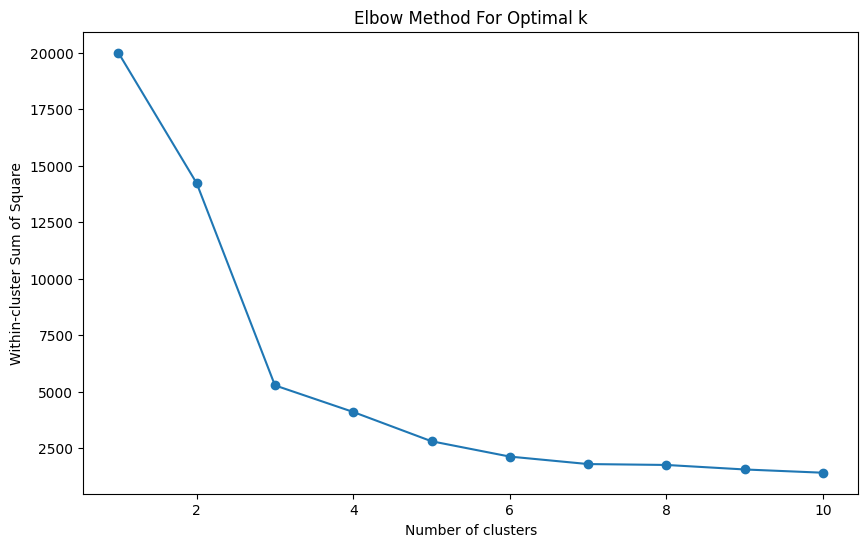

In [246]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def cluster_data(df_decade):
    # Step 1: Standardize the data
    scaler = StandardScaler()
    df_decade_scaled = df_decade.copy()
    df_decade_scaled.iloc[:, :] = scaler.fit_transform(df_decade)
    inertia = []
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, random_state=42)
        kmeans.fit(df_decade_scaled)
        inertia.append(kmeans.inertia_)
    # Plot the elbow graph
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 11), inertia, marker='o')
    plt.title('Elbow Method For Optimal k')
    plt.xlabel('Number of clusters')
    plt.ylabel('Within-cluster Sum of Square')
    plt.show()
    return df_decade_scaled

scaled_spatial_data = cluster_data(spatial_data)


In [247]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['SpatialCluster'] = kmeans.fit_predict(scaled_spatial_data)
# Extract cluster centers
centers = kmeans.cluster_centers_
spatial_radii = []
# Verify that the data and cluster centers are aligned
print("Cluster Centers:\n", centers)

# Loop through each cluster and check distances
for i in range(4):
    cluster_points = scaled_spatial_data[df['SpatialCluster'] == i]
    
    # Ensure that there are points in this cluster
    if cluster_points.empty:
        print(f"Warning: No points found for cluster {i}")
        continue

    # print(f"\nCluster {i} Points:\n", cluster_points[:2])
    
    # Calculate the distances
    distances = np.linalg.norm(cluster_points - centers[i], axis=1)
    # print(f"Distances for Cluster {i}:\n", distances[:2])  # Show first 5 distances to check
    
    # Calculate the maximum distance
    max_distance = max(distances)
    # print(f"Max Distance for Cluster {i}: {max_distance}")
    spatial_radii.append(max_distance)

print (spatial_radii)

Cluster Centers:
 [[ 0.50248988  0.55504347]
 [-0.06065886 -1.39993129]
 [-0.10976737  0.00693142]
 [-4.61465503  2.48283245]]
[2.4617281893965495, 5.088232490513947, 2.5335192992388413, 2.9751677880305882]


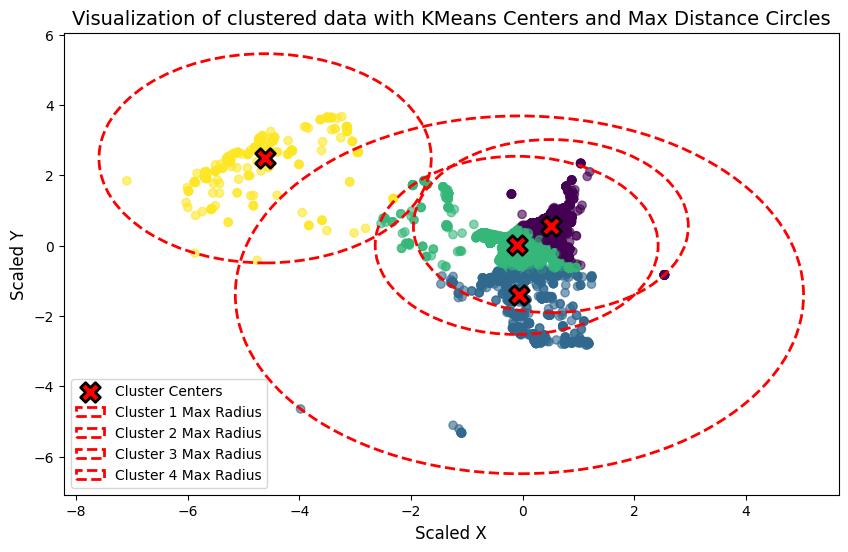

In [248]:

# Create scatter plot of clusters
plt.figure(figsize=(10, 6))
plt.scatter(scaled_spatial_data['normLatitude'], scaled_spatial_data['normLongitude'], c=df['SpatialCluster'], cmap='viridis', marker='o', alpha=0.6)

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', edgecolors='k', linewidths=2, label='Cluster Centers')

# Plot circles around each cluster center
for i, radius in enumerate(spatial_radii):
    circle = plt.Circle((centers[i, 0], centers[i, 1]), radius, color='red', fill=False, linestyle='--', linewidth=2, label=f'Cluster {i+1} Max Radius')
    plt.gca().add_patch(circle)

# Set plot labels and title
plt.title('Visualization of clustered data with KMeans Centers and Max Distance Circles', fontsize=14)
plt.xlabel('Scaled X', fontsize=12)
plt.ylabel('Scaled Y', fontsize=12)
plt.legend()
plt.show()

In [249]:
spatial_centers = kmeans.cluster_centers_
spatial_radii = []
for i in range(3):
        cluster_points = scaled_spatial_data[df['SpatialCluster'] == i]
        max_distance = max(np.linalg.norm(cluster_points - spatial_centers[i], axis=1))
        spatial_radii.append(max_distance)
        

In [250]:
text_data = df[['text']]
text_data.head()

,text
0,World's #Deadliest Elite Special Forces In #Ma...
1,Yoooo my substitute is extremely attractive �?😛
2,Stopped for speeding at an invisible crosswalk...
3,The Spring Break is upon us. https://t.co/6JK2...
4,I can't believe I saw Abel twice within 6 mont...


In [251]:
text_data['totalwords'] = text_data['text'].str.count(' ') + 1
text_data.describe

C:\Users\kosta\AppData\Local\Temp\ipykernel_6020\2307666330.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_data['totalwords'] = text_data['text'].str.count(' ') + 1


<bound method NDFrame.describe of                                                    text  totalwords
0     World's #Deadliest Elite Special Forces In #Ma...           9
1       Yoooo my substitute is extremely attractive �?😛           7
2     Stopped for speeding at an invisible crosswalk...           9
3     The Spring Break is upon us. https://t.co/6JK2...           7
4     I can't believe I saw Abel twice within 6 mont...          12
...                                                 ...         ...
9995  Kudos 2 @BronwynBeightol 4 capturing the tapes...          13
9996                             @jsepulveda38 really?😻           2
9997  https://t.co/FX0IzS5JFd and just back when I w...          12
9998  I hate when niggas be like "tonight finna be a...          19
9999  �So much weirdness dry wit &amp; je ne sais qu...          18

[10000 rows x 2 columns]>

In [252]:
# Keeps the rows that totalwords > 3
text_data=text_data.loc[text_data['totalwords'] > 3]
text_data.describe

<bound method NDFrame.describe of                                                    text  totalwords
0     World's #Deadliest Elite Special Forces In #Ma...           9
1       Yoooo my substitute is extremely attractive �?😛           7
2     Stopped for speeding at an invisible crosswalk...           9
3     The Spring Break is upon us. https://t.co/6JK2...           7
4     I can't believe I saw Abel twice within 6 mont...          12
...                                                 ...         ...
9994               @JLane0410 About time! Thanks girl 😘           6
9995  Kudos 2 @BronwynBeightol 4 capturing the tapes...          13
9997  https://t.co/FX0IzS5JFd and just back when I w...          12
9998  I hate when niggas be like "tonight finna be a...          19
9999  �So much weirdness dry wit &amp; je ne sais qu...          18

[9227 rows x 2 columns]>

In [268]:
# Remove stopwords using Gensim
text_data['text'].apply(remove_stopwords)
text_data.text[0]

"World's #Deadliest Elite Special Forces In #Malaysia https://t.co/TGVe19Ujnf https://t.co/9C2EjQg2KT"

In [269]:
text_sentences = [line.split() for line in text_data.text]
print(text_sentences)

[["World's", '#Deadliest', 'Elite', 'Special', 'Forces', 'In', '#Malaysia', 'https://t.co/TGVe19Ujnf', 'https://t.co/9C2EjQg2KT'], ['Yoooo', 'substitute', 'extremely', 'attractive', '�?😛'], ['Stopped', 'speeding', 'invisible', 'crosswalk...', 'Hello', 'Friday.🙄'], ['The', 'Spring', 'Break', 'us.', 'https://t.co/6JK2YPTKdH'], ['I', "can't", 'believe', 'I', 'saw', 'Abel', 'twice', '6', 'months', 'year'], ['@BritneySpears', 'thank', 'till', 'world', 'ends.', 'I', "can't", 'believe', "it's", 'years', 'gave', 'record.', '☀�?'], ['@TheMikeBagley', 'I', 'thought', '@LVMotorSpeedway', '@PRNlive', '@MRNRadio', "we'll", 'listening', 'way', 'enjoy', 'Las', 'Vegas', 'happened', 'w/ladie'], ['You', 'fucking', 'best', '.'], ["Can't", 'wait', 'https://t.co/WJNxAbFIQ3'], ['Meanwhile', 'I', 'want', '40', 'https://t.co/xAwO8gPszP'], ["that's", 'proud', 'nice..'], ['Really', 'solid', 'game', '@NHLBruins', 'night.', 'Liles', 'looks', 'good.', '#team', '#NHL', '#effort'], ["I'm", 'Casa', 'Edward', 'https:/

In [281]:
import gensim
from gensim.models import KeyedVectors

model = gensim.models.Word2Vec(text_sentences)
# print(model.wv.index_to_key)
# model.wv.most_similar(positive=['&amp;'], topn = 3)

print(model.wv.most_similar('trump'))


[('lol', 0.997701108455658), ('little', 0.9976879358291626), (',', 0.9976799488067627), ('class', 0.997663140296936), ('man', 0.9976515769958496), ('let', 0.997651219367981), ('2', 0.997648298740387), ('Your', 0.997647225856781), ('5', 0.9976348876953125), ('&amp;', 0.9976281523704529)]


In [257]:
# print(w2v.wv.index_to_key)